# 2. Learning spatial relationships with MISTy

While Moran's R provides a sound summary of spatial clustering, it is limited to two variables at a time and is thus not fit for complex, or non-linear, spatial relationships between variables. 

Here, we show how to use LIANA's implementation of [MISTy](https://github.com/saezlab/mistyR), a framework presented in [Tanevski et al., 2022](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-022-02663-5).

MISTy is a tool that helps us better understand how different features, such as genes or cell types, interact with each other in space. MISTy does so by learning both **intra-** and **extracellular** relationships - i.e. those that occur within and between cells/spots. A major advantage of MISTy is its flexibility. It can model different perspectives, or "views," each describing a different way markers are related to each other. Each of these views can describe a different spatial context, i.e. define a relationship among the observed expressions of the markers, such as intracellular regulation or paracrine regulation.

MISTy has only one fixed view - i.e. the intraview, which contains the target (dependent) variables. The other views we refer to as extra views, and they contain the independent variables used to predict the intra view. MISTy can fit any number of extra views, and each extra view can contain any number of variables. The extra views can thus simultaneously learn the dependencies of target variables across different modalities, such as cell type proportions, pathways, or genes, etc.

MISTy represents each view represents as a potential source of variation in the measurements of the target  variables in the intra view. MISTy further analyzes each view to determine how it contributes to the overall expression or abundance of each target variable. It explains this contribution by identifying the interactions between measurements that led to the observed results.



### Import packages

In [1]:
import scanpy as sc
import squidpy as sq
from matplotlib import pyplot as plt
import decoupler as dc
import plotnine as p9
import liana as li

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Import functions needed to create MISTy objects.

In [2]:
from liana.method import MistyData, genericMistyData, lrMistyData

### Import Pre-defined Single view models

In [3]:
from liana.method.sp import RandomForestModel, LinearModel, RobustLinearModel

### Load and Normalize Data

We use the same Visium slide from [Kuppe et al., 2022](https://www.nature.com/articles/s41586-022-05060-x).

In [4]:
# li.ds caches downloads under ../../data/anndata; a provided Visium_19_CK297.h5ad there is used as-is
sc.settings.datasetdir = "../../data"
adata = li.ds.kuppe_2022()

In [5]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

##### Extract Cell type Composition
This slide comes with estimated cell type proportions using cell2location; See [Kuppe et al., 2022](https://www.nature.com/articles/s41586-022-05060-x). Let's extract from .obsm them to an independent AnnData object.

In [6]:
# Rename to more informative names
full_names = {'Adipo': 'Adipocytes',
              'CM': 'Cardiomyocytes',
              'Endo': 'Endothelial',
              'Fib': 'Fibroblasts',
              'PC': 'Pericytes',
              'prolif': 'Proliferating',
              'vSMCs': 'Vascular_SMCs',
              }
# but only for the ones that are in the data
adata.obsm['compositions'].columns = [full_names.get(c, c) for c in adata.obsm['compositions'].columns]

In [7]:
comps = li.pp.obsm_to_adata(adata, 'compositions')

In [8]:
comps.var

""
Adipocytes
Cardiomyocytes
Endothelial
Fibroblasts
Lymphoid
Mast
Myeloid
Neuronal
Pericytes
Proliferating


/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


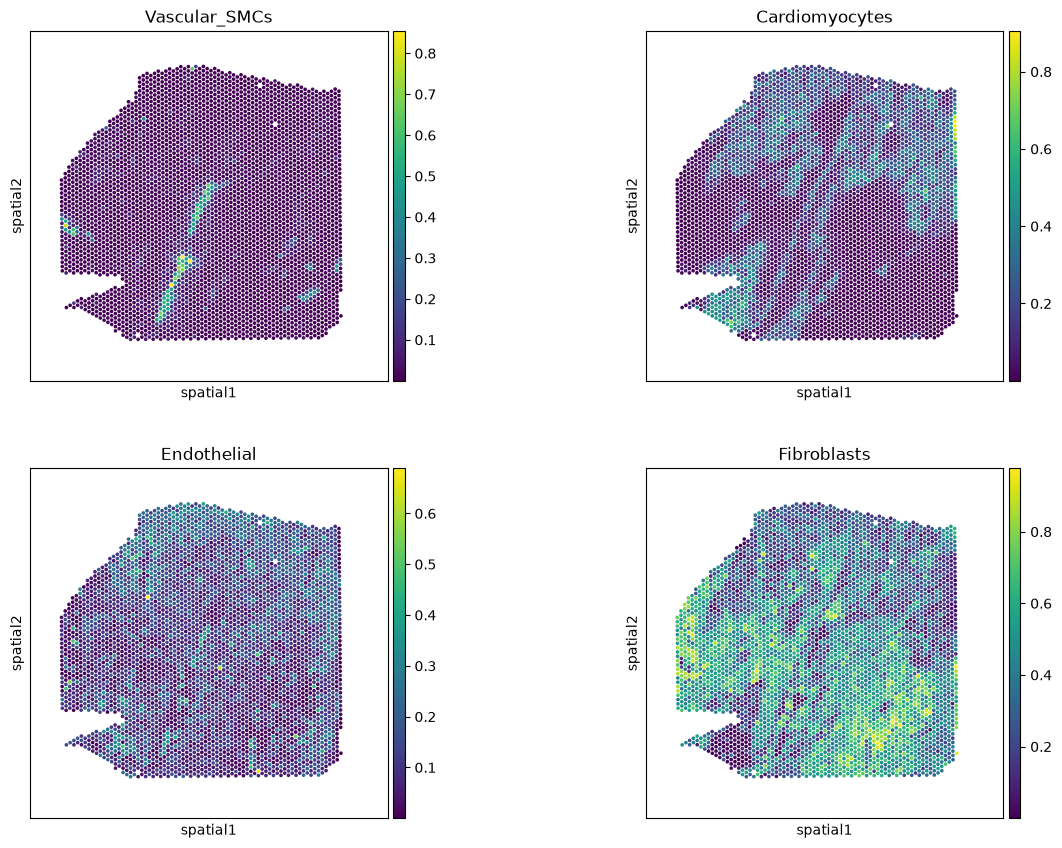

In [9]:
# check key cell types
sq.pl.spatial_scatter(comps,
                       color=['Vascular_SMCs','Cardiomyocytes',
                              'Endothelial', 'Fibroblasts'],
                       size=1.3, ncols=2, img_alpha=0
                       )
plt.show()

## Formatting & Running MISTy


The implementation of MISTy in LIANA relies on [MuData](https://github.com/scverse/mudata) objects [(Bredikhin et al., 2022)](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-021-02577-8) and extends them to a very simple child class we call "MistyData". 
To make it easier to use, we provide functions to construct "MistyData" objects that transform the data into a format that MISTy can use.

Briefly, a "MistyData" object is just a MuData object with **intra** as one of the modalities - this is the view in which the (**target**) variables explained by all other views are stored. 
MISTy is flexible to any other view that is appended, provided it also contains a spatial neighbors graph.


Let's use `genericMistyData` to construct a MuData object with the intra view and the cell type proportions as the first view.
Then it additionally build a 'juxta' view for the spots that are neighbors of each other, and a 'para' view for all surrounding spots within a certain radius, or bandwidth.

Here, we use the cell type proportions as the intra view.

In [10]:
misty = genericMistyData(intra=comps, cutoff=0.05, bandwidth=200, n_neighs=6)

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/liana/method/sp/_misty/_Misty.py:143: ImplicitModificationWarning: Setting element `.layers['weighted']` of view, initializing view as actual.
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/liana/method/sp/_misty/_Misty.py:143: ImplicitModificationWarning: Setting element `.layers['weighted']` of view, initializing view as actual.


In [11]:
misty

MuData object with n_obs × n_vars = 4113 × 33
  obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche'
  3 modalities
    intra:	4113 × 11
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche'
      obsm:	'spatial'
      layers:	None
    juxta:	4113 × 11
      obsm:	'spatial'
      layers:	None, 'weighted'
      obsp:	'spatial_connectivities'
    para:	4113 × 11
      obsm:	'spatial'
      layers:	None, 'weighted'
      obsp:	'spatial_connectivities'

## Learn Relationships with MISTy


In [12]:

misty(model=LinearModel, k_cv=10, seed=1337, verbose = True)

#misty(model=RandomForestModel, n_jobs=-1, verbose = True) # you can also use RandomForestModel but it takes longer time

  0%|          | 0/11 [00:00<?, ?it/s]

Now learning: Adipocytes:   0%|          | 0/11 [00:00<?, ?it/s]

Now learning: Adipocytes:   9%|▉         | 1/11 [00:00<00:02,  4.86it/s]

Now learning: Cardiomyocytes:   9%|▉         | 1/11 [00:00<00:02,  4.86it/s]

Now learning: Endothelial:   9%|▉         | 1/11 [00:00<00:02,  4.86it/s]   

...

Now learning: Pericytes:  64%|██████▎   | 7/11 [00:00<00:00, 18.01it/s]

Now learning: Proliferating:  64%|██████▎   | 7/11 [00:00<00:00, 18.01it/s]

Now learning: Proliferating:  91%|█████████ | 10/11 [00:00<00:00, 20.28it/s]

Now learning: Vascular_SMCs:  91%|█████████ | 10/11 [00:00<00:00, 20.28it/s]

Now learning: Vascular_SMCs: 100%|██████████| 11/11 [00:00<00:00, 17.75it/s]

Specifically, we will use the `LinearModel` to fit an linear model for each target in the intra view, using the juxta and para views as predictors. It is a bit more simplistic but much faster and more interpretable.
You can also use `RandomForestModel` but it takes longer time

MISTy returns two DataFrames:
* `target_metrics` - the metrics that describe the target variables from the intra view, including R-squared across different views as well as the estimated contributions to the predictive performance of each view per target.
* `interactions` - feature importances per view

if `inplace` is true (Default), these are appended to the MuData object.


check the variance explained when predicting each target variables in the intra view, with other variables (predictors) in the intra view itself


In [13]:
misty.uns['target_metrics']

,target,intra_R2,multi_R2,gain_R2,intra,juxta,para
0,Adipocytes,0.844900,0.852572,7.672018e-03,0.770425,0.138771,0.090804
1,Cardiomyocytes,0.999998,0.999994,-4.458427e-06,0.995422,0.004578,0.000000
2,Endothelial,0.999990,0.999987,-3.069639e-06,0.995912,0.003779,0.000309
3,Fibroblasts,1.000000,0.999999,-3.874302e-07,0.998713,0.001198,0.000089
4,Lymphoid,0.997506,0.997400,-1.053870e-04,0.957057,0.029626,0.013317
5,Mast,0.987960,0.987883,-7.682443e-05,0.935108,0.055071,0.009821
6,Myeloid,0.999995,0.999991,-3.659725e-06,0.996114,0.003591,0.000294
7,Neuronal,0.999962,0.999938,-2.444983e-05,0.989834,0.009276,0.000890
8,Pericytes,0.999925,0.999894,-3.021955e-05,0.987689,0.011099,0.001212
9,Proliferating,0.999935,0.999894,-4.044771e-05,0.986904,0.012668,0.000429


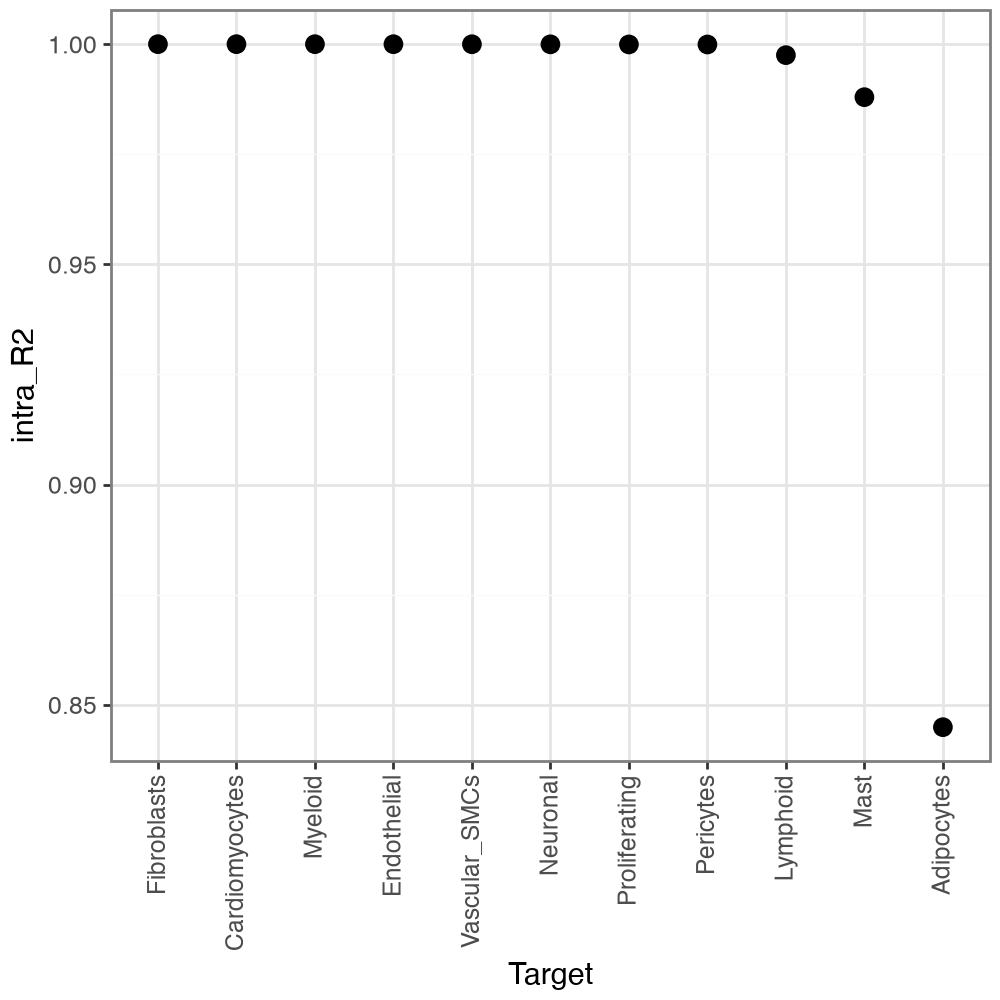

In [14]:
li.pl.misty_target_metrics(misty, stat='intra_R2', return_fig=True)

MISTy additionally calculate `gain_R2`, or in other words the performance gain when we additionally consider the other views (in addition to intra). When we look at the variance explained by the other views, we see that they explain a bit less (as expected), but still there is still some gain of predictive performance:

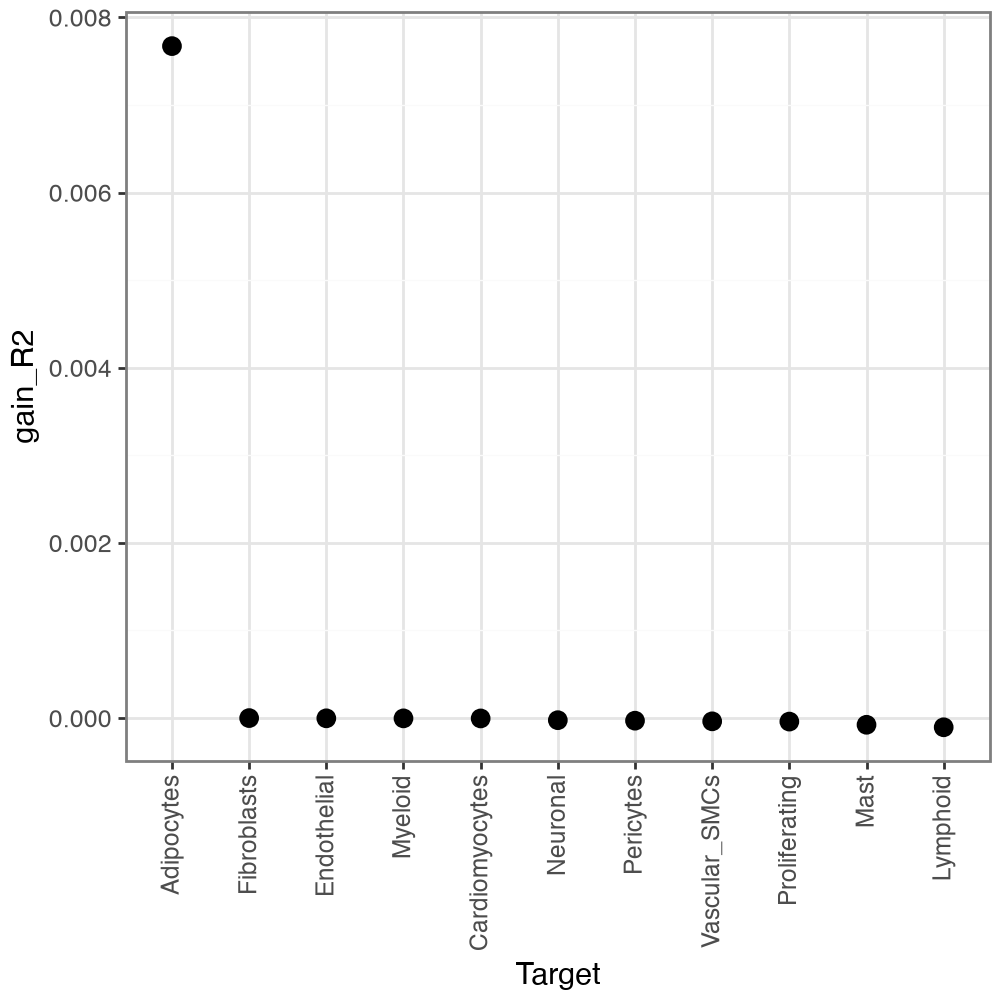

In [15]:
li.pl.misty_target_metrics(misty, stat='gain_R2', return_fig=True)

We can also check the contribution to the predictive performance of each view per target:

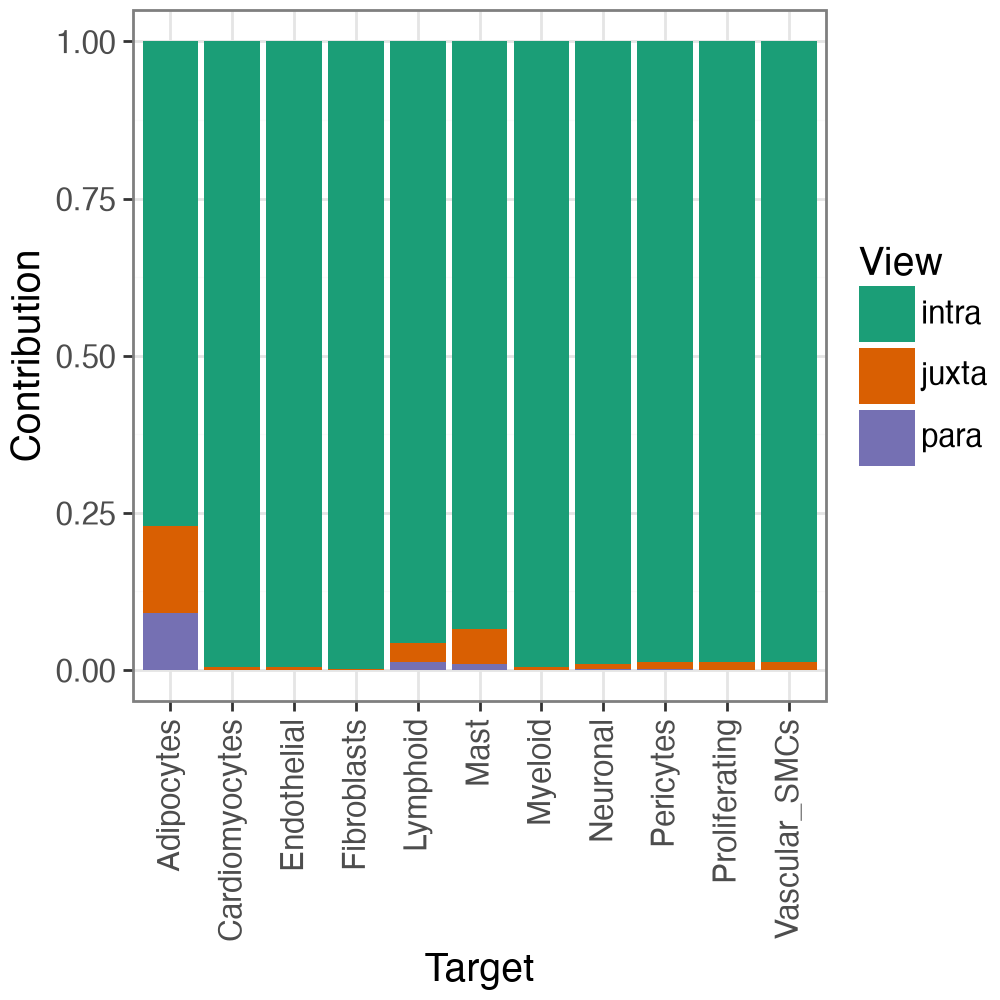

In [16]:
li.pl.misty_contributions(misty, return_fig=True)

### Add pathway activities as extra view

We can also use estimated pathway activities as extra views to make the data a bit more interpretable.
We will use [decoupler-py](https://academic.oup.com/bioinformaticsadvances/article/2/1/vbac016/6544613) with pathways genesets from [PROGENy](https://www.nature.com/articles/s41467-017-02391-6). See [this tutorial](https://decoupler-py.readthedocs.io/en/latest/notebooks/spatial.html) for details.

In [17]:
# obtain genesets
progeny = dc.op.progeny(organism='human', top=100)

In [18]:
# use univariate linear model to estimate activity
dc.mt.ulm(
    adata,
    net=progeny,
    tmin=5,
    verbose=True,
    bsize = 256,
    raw=False
)

2026-09-25 17:14:18 | [INFO] ulm - Running ulm


ulm - Running ulm


2026-09-25 17:14:18 | [INFO] Extracted omics mat with 4113 rows (observations) and 17703 columns (features)


Extracted omics mat with 4113 rows (observations) and 17703 columns (features)


2026-09-25 17:14:18 | [INFO] Network adjacency matrix has 1102 unique features and 14 unique sources


...

100%|██████████| 17/17 [00:00<00:00, 55.46it/s]


2026-09-25 17:14:19 | [INFO] ulm - adjusting p-values by FDR


ulm - adjusting p-values by FDR


2026-09-25 17:14:19 | [INFO] ulm - done


ulm - done


In [19]:
# extract progeny activities as an AnnData object
acts_progeny = li.pp.obsm_to_adata(adata, 'score_ulm')

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


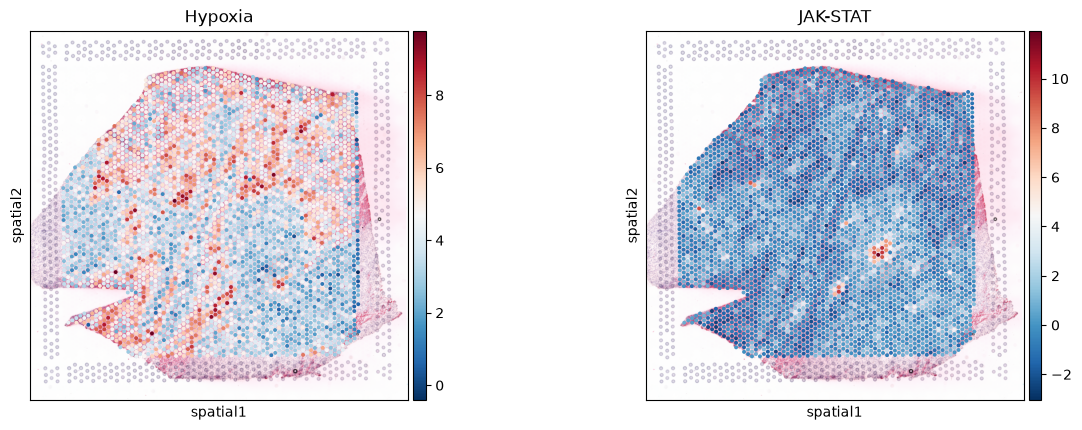

In [20]:
# Check how the pathway activities look like
sq.pl.spatial_scatter(acts_progeny, color=['Hypoxia', 'JAK-STAT'], cmap='RdBu_r', size=1.3)
plt.show()

In this case, we will use cell type compositions per spot as the intra view, and we will use the PROGENy pathway activities to define the juxta and para views:

In [21]:
misty = genericMistyData(intra=comps, extra=acts_progeny, cutoff=0.05, bandwidth=200, n_neighs=6)

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/liana/method/sp/_misty/_Misty.py:143: ImplicitModificationWarning: Setting element `.layers['weighted']` of view, initializing view as actual.
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/liana/method/sp/_misty/_Misty.py:143: ImplicitModificationWarning: Setting element `.layers['weighted']` of view, initializing view as actual.


In [22]:
misty

MuData object with n_obs × n_vars = 4113 × 39
  obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche'
  3 modalities
    intra:	4113 × 11
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche'
      obsm:	'spatial'
      layers:	None
    juxta:	4113 × 14
      obsm:	'spatial'
      layers:	None, 'weighted'
      obsp:	'spatial_connectivities'
    para:	4113 × 14
      obsm:	'spatial'
      layers:	None, 'weighted'
      obsp:	'spatial_connectivities'

#### Run MISTy with pathway views

 we will **bypass** predicting the intraview with features within the intraview features (`bypass_intra`).
This will allow us to see how well the other views explain the intraview, excluding the intraview itself.

In [23]:
misty(model=LinearModel, k_cv=10, seed=1337, bypass_intra=True, verbose = True)

  0%|          | 0/11 [00:00<?, ?it/s]

Now learning: Adipocytes:   0%|          | 0/11 [00:00<?, ?it/s]

Now learning: Cardiomyocytes:   0%|          | 0/11 [00:00<?, ?it/s]

Now learning: Endothelial:   0%|          | 0/11 [00:00<?, ?it/s]   

Now learning: Fibroblasts:   0%|          | 0/11 [00:00<?, ?it/s]

...

Now learning: Neuronal:  73%|███████▎  | 8/11 [00:00<00:00, 34.63it/s]

Now learning: Pericytes:  73%|███████▎  | 8/11 [00:00<00:00, 34.63it/s]

Now learning: Proliferating:  73%|███████▎  | 8/11 [00:00<00:00, 34.63it/s]

Now learning: Vascular_SMCs:  73%|███████▎  | 8/11 [00:00<00:00, 34.63it/s]

Now learning: Vascular_SMCs: 100%|██████████| 11/11 [00:00<00:00, 34.78it/s]

Let's check the joined R-squared for views:

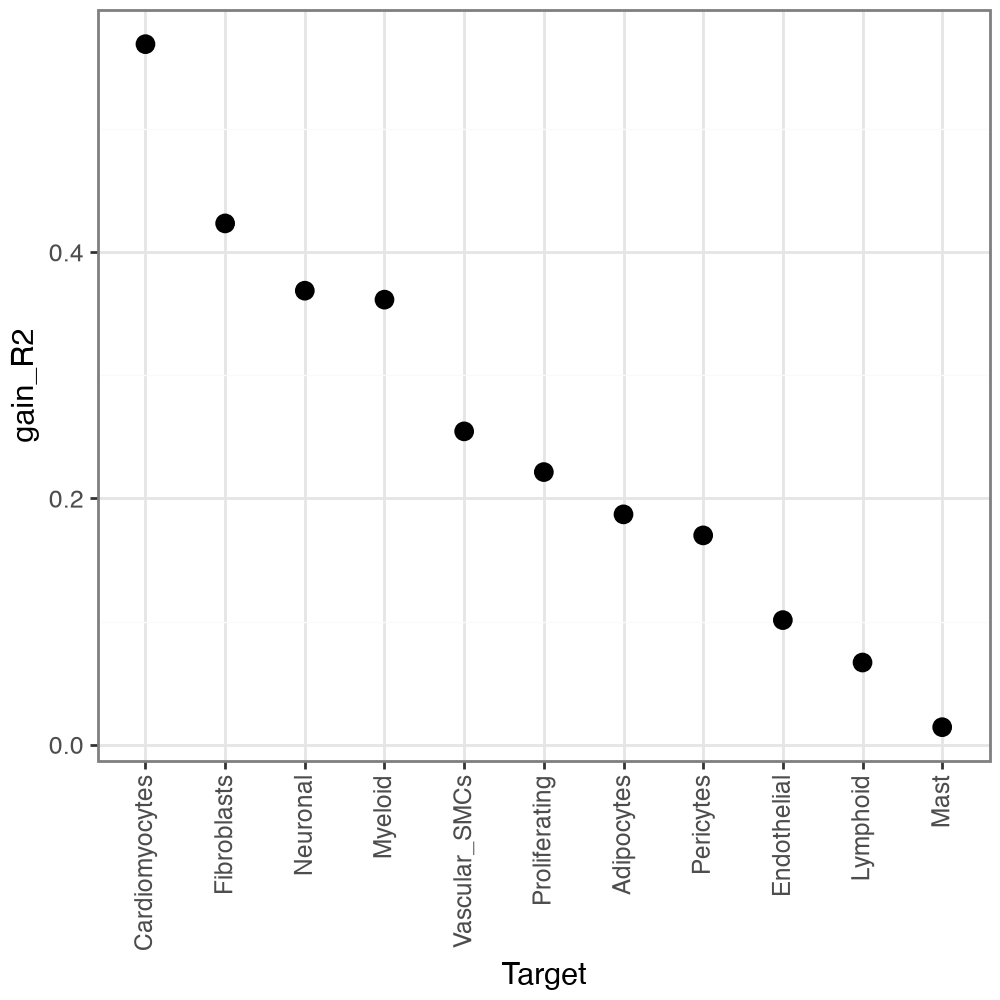

In [24]:
li.pl.misty_target_metrics(misty, stat='gain_R2', return_fig=True)

Finally, using the information above we know which variables are best explained by our model, and we know which view explains them best. 
So, we can now also see what are the specific variables that explain each target best:

In [25]:
# this information is stored here:
misty.uns['interactions'].head()

,target,predictor,view,importances
0,Adipocytes,Androgen,juxta,0.506324
1,Adipocytes,EGFR,juxta,-0.446769
2,Adipocytes,Estrogen,juxta,4.414592
3,Adipocytes,Hypoxia,juxta,11.538168
4,Adipocytes,JAK-STAT,juxta,0.111442


and their contributions per target:

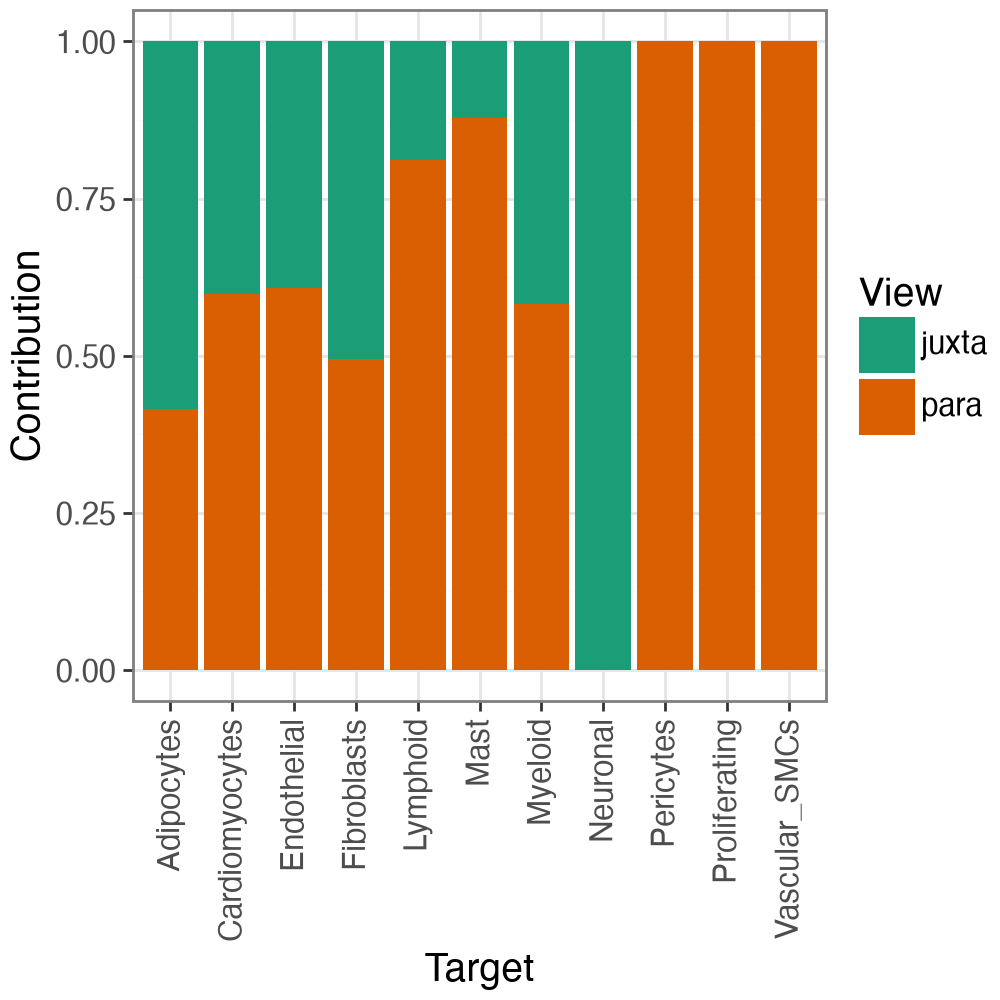

In [26]:
li.pl.misty_contributions(misty, return_fig=True)

Since this is a linear model, the coefficients would not be directly comparable (as are importances in a Random Forest). Thus, we use the coefficients' t-values, as calculated by Ordinary Least Squares, which are signed and directly comparable.

Let's explore the t-values for each target-prediction interaction:

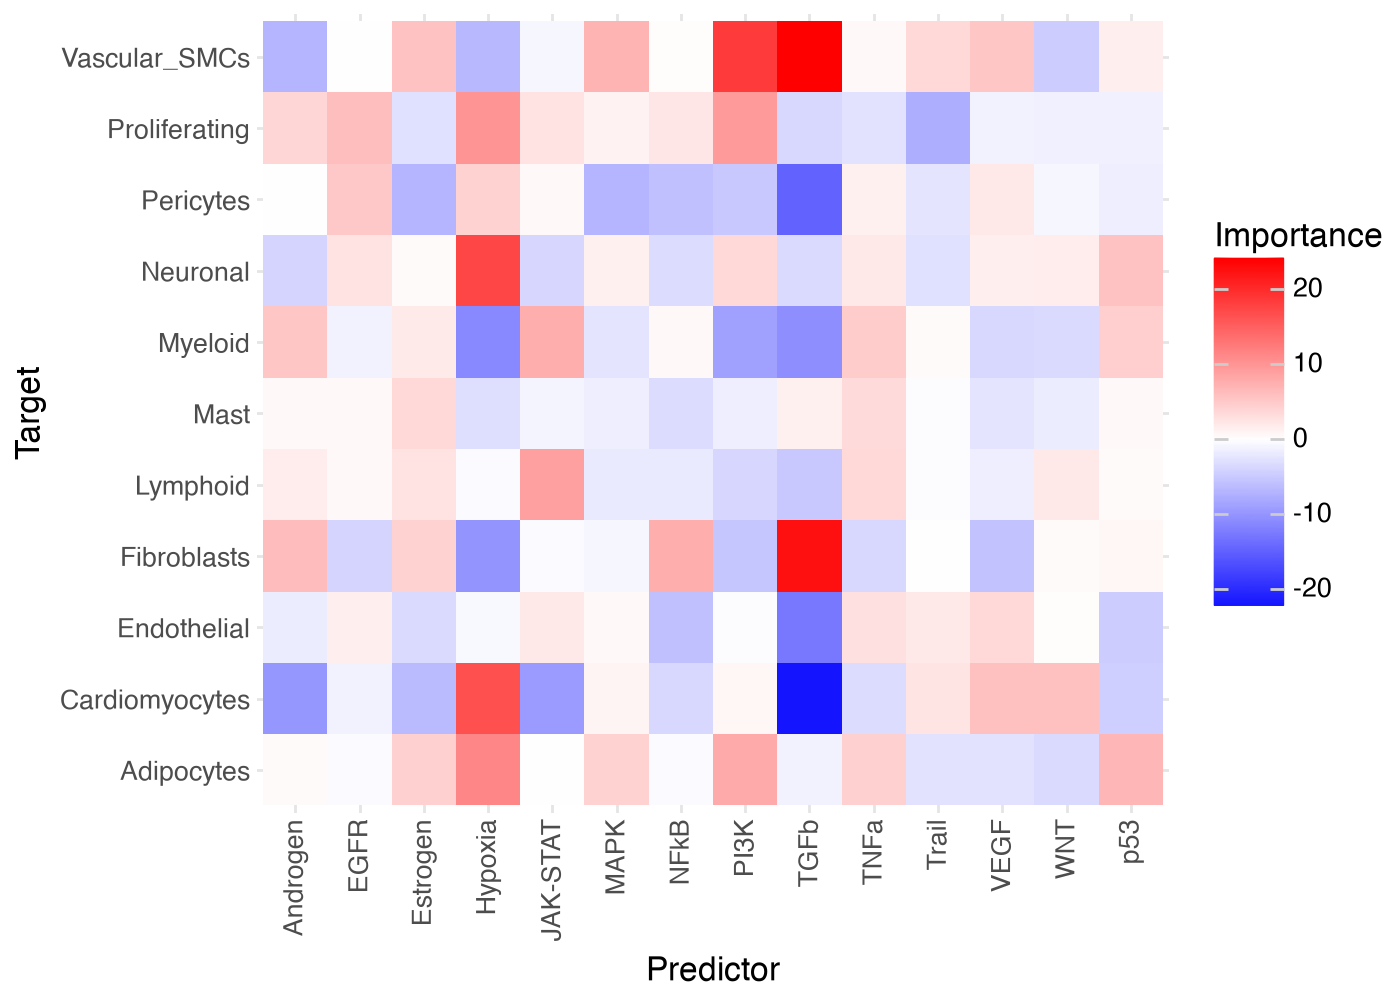

In [27]:
(
    li.pl.misty_interactions(misty, view='juxta', return_fig=True, figure_size=(7,5)) + 
    p9.scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0)
)

<div class="alert alert-info">
    
<h4> Feature importances </h4>

By default, we use a random forest, so the feature importances are the mean decrease in Gini impurity of the features. On the other hand, when we use a linear model, the feature importances are the t-values of the model coefficients.


</div>  

## Build Custom Misty Views

As we previously mentioned, one can build any view structure that they deem relevant for their data.
So, let's explore how to build custom views.
Here, we will just use two distinct prior knowledge sources to check which one achieves better predictive performance.

So, let's also estimate Transcription Factor activities with decoupler:

In [28]:
# get TF prior knowledge
net = dc.op.collectri(organism='human', remove_complexes=True, license='academic', verbose=False)

In [29]:
# Estimate activities
dc.mt.ulm(
    data=adata,
    net=net,
    bsize=128,  
    tmin = 50,
    verbose=True,
    raw=False
)

2026-09-25 17:14:21 | [INFO] ulm - Running ulm


ulm - Running ulm


2026-09-25 17:14:21 | [INFO] Extracted omics mat with 4113 rows (observations) and 17703 columns (features)


Extracted omics mat with 4113 rows (observations) and 17703 columns (features)


2026-09-25 17:14:21 | [INFO] Network adjacency matrix has 4750 unique features and 170 unique sources


...

100%|██████████| 33/33 [00:00<00:00, 47.38it/s]


2026-09-25 17:14:21 | [INFO] ulm - adjusting p-values by FDR


ulm - adjusting p-values by FDR


2026-09-25 17:14:21 | [INFO] ulm - done


ulm - done


In [30]:
# extract activities
acts_tfs = li.pp.obsm_to_adata(adata, 'score_ulm')

In [31]:
# Calculate spatial neighbors
li.pp.spatial_neighbors(acts_tfs, cutoff=0.1, bandwidth=200, set_diag=True) # you can also set set_diag=False

Visualize the weights for a specific spot:

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_88157/3931196721.py:1: UserWarning: This function will be deprecated in the next version. Please use scanpy or squidpy for plotting spatial connectivities.


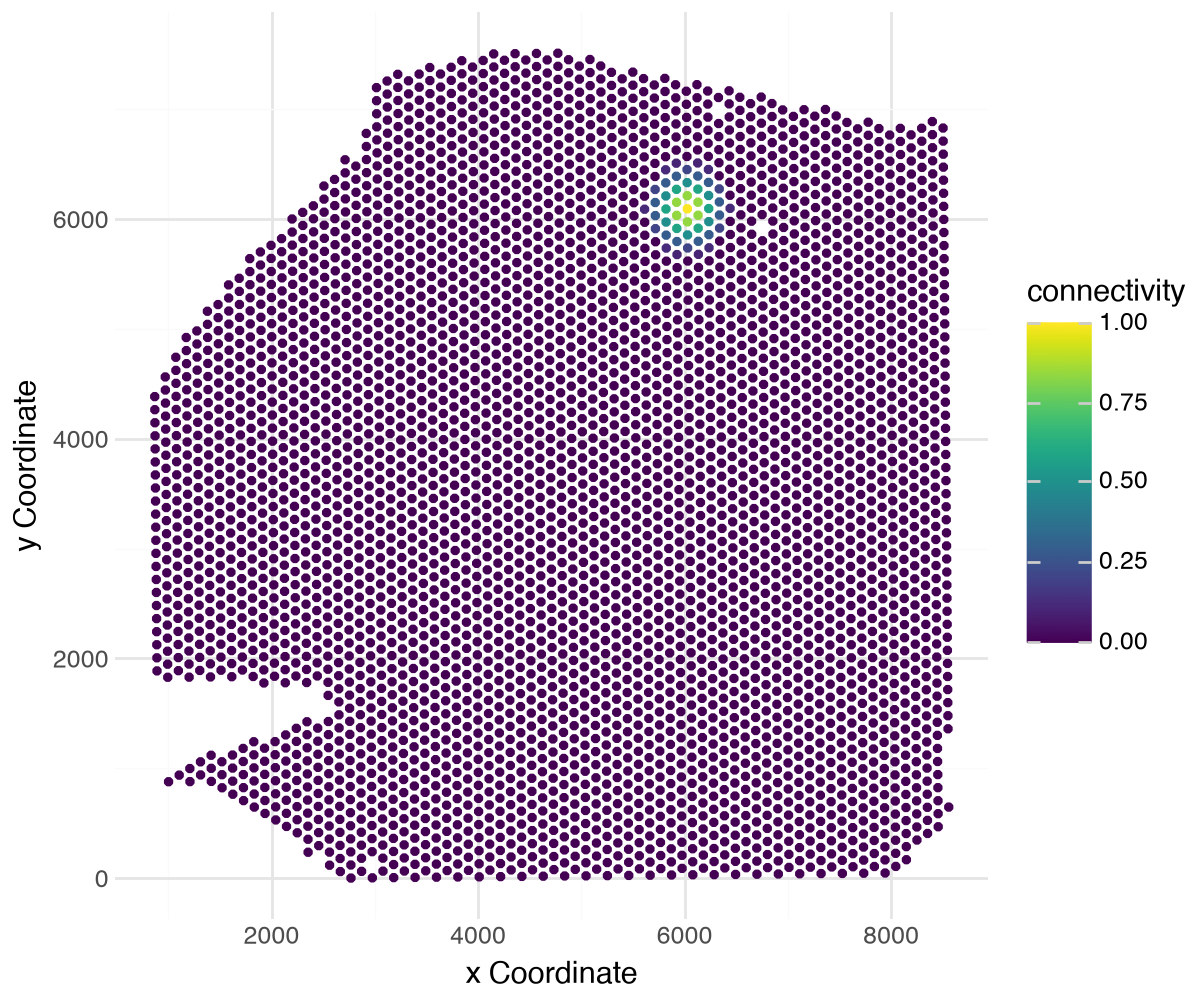

In [32]:
li.pl.connectivity(acts_tfs, idx=0, figure_size=(6,5))

In [33]:
# transfer spatial information to progeny activities
# NOTE: spatial connectivities can differ between views, but in this case we will use the same
acts_progeny.obsm['spatial'] = acts_tfs.obsm['spatial']
acts_progeny.obsp['spatial_connectivities'] = acts_tfs.obsp['spatial_connectivities']

Build an object with custom views:

In [34]:
misty = MistyData(data={"intra": comps, "TFs": acts_tfs, "Pathways": acts_progeny})

In [35]:
misty

MuData object with n_obs × n_vars = 4113 × 195
  obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche'
  3 modalities
    intra:	4113 × 11
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche'
      uns:	'spatial', 'log1p'
      obsm:	'compositions', 'mt', 'spatial'
      layers:	None
    TFs:	4113 × 170
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 

Run Misty as before:

In [36]:
misty(model=LinearModel, k_cv=5, seed=1337, bypass_intra=True, verbose = True)

  0%|          | 0/11 [00:00<?, ?it/s]

Now learning: Adipocytes:   0%|          | 0/11 [00:00<?, ?it/s]

Now learning: Cardiomyocytes:   0%|          | 0/11 [00:00<?, ?it/s]

Now learning: Cardiomyocytes:  18%|█▊        | 2/11 [00:00<00:00, 11.28it/s]

Now learning: Endothelial:  18%|█▊        | 2/11 [00:00<00:00, 11.28it/s]   

...

Now learning: Pericytes:  73%|███████▎  | 8/11 [00:00<00:00, 11.57it/s]

Now learning: Proliferating:  73%|███████▎  | 8/11 [00:00<00:00, 11.57it/s]

Now learning: Proliferating:  91%|█████████ | 10/11 [00:00<00:00,  9.83it/s]

Now learning: Vascular_SMCs:  91%|█████████ | 10/11 [00:00<00:00,  9.83it/s]

Now learning: Vascular_SMCs: 100%|██████████| 11/11 [00:01<00:00, 10.56it/s]

We can see that Cardiomyocytes and Fibroblasts are relatively well explained by TFs & Pathways.

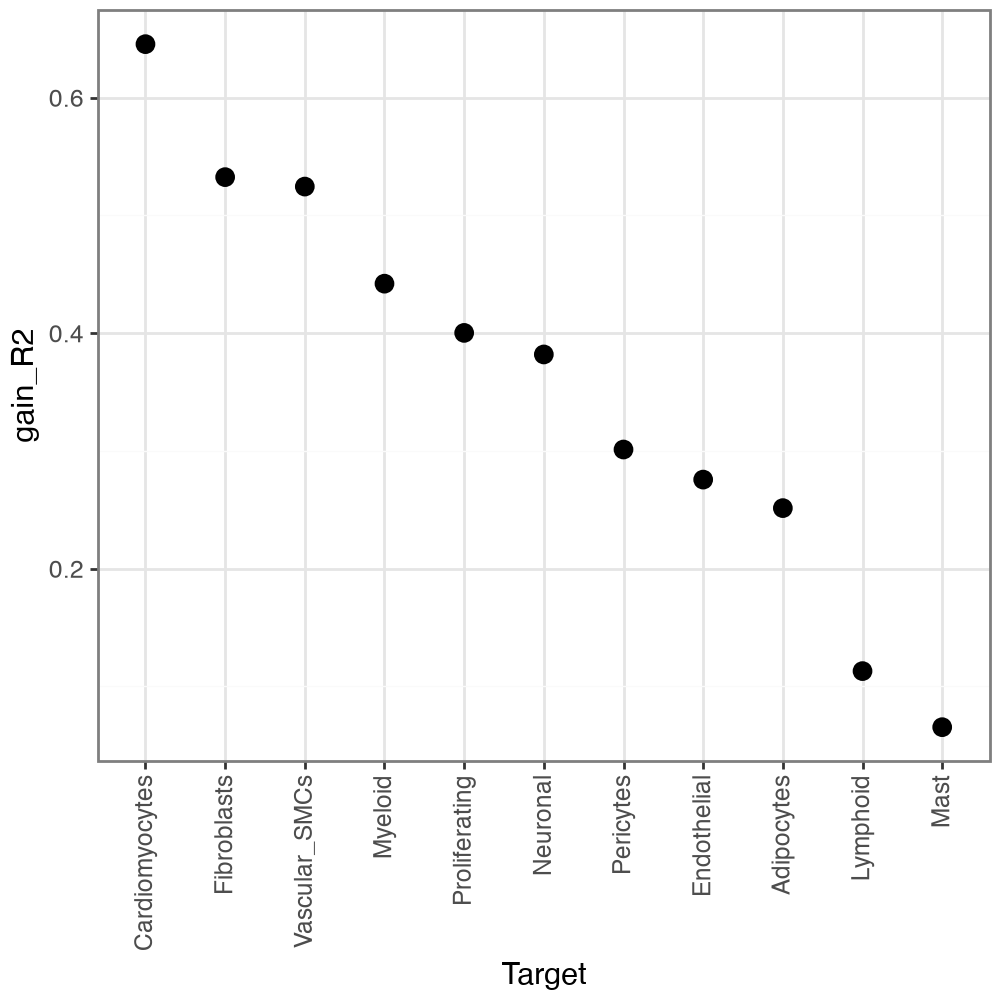

In [37]:
li.pl.misty_target_metrics(misty, stat='gain_R2')

We also see that the two views explain the targets similarly well.

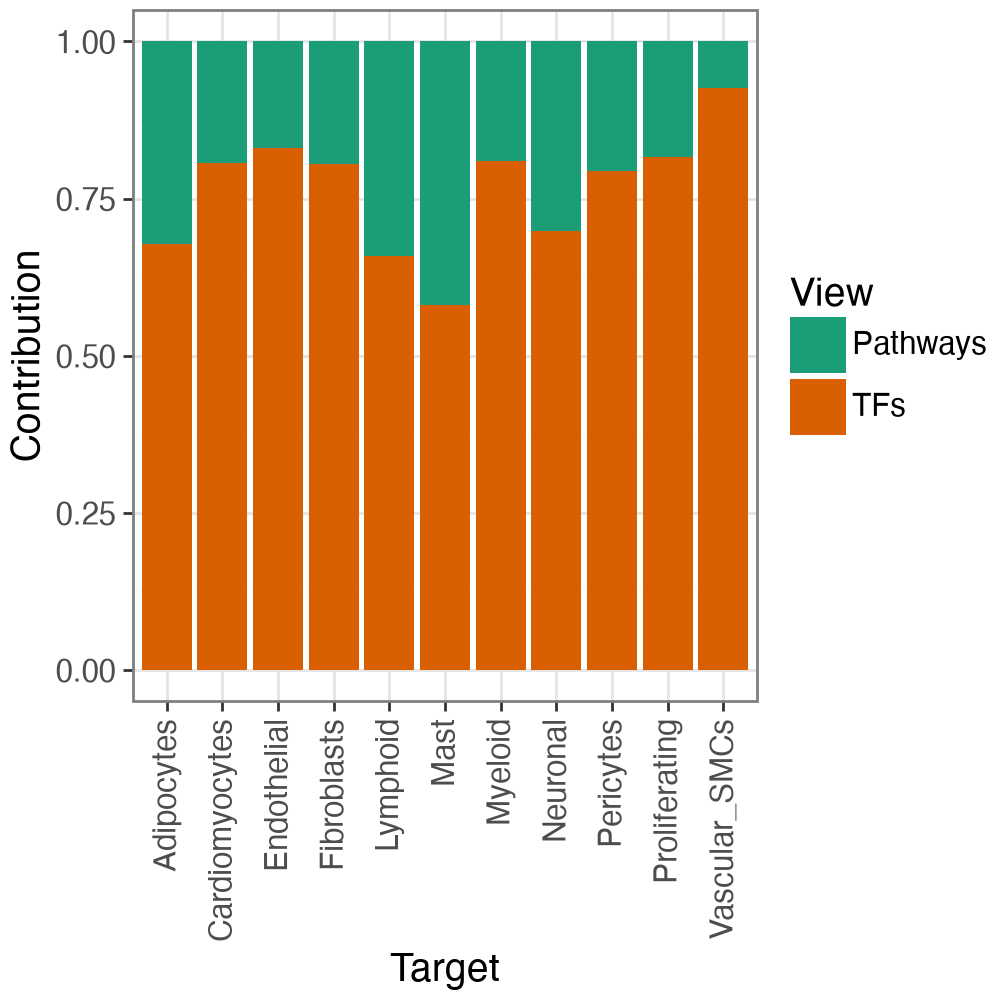

In [38]:
li.pl.misty_contributions(misty, return_fig=True)

Plot cell type x Trascription factor interactions

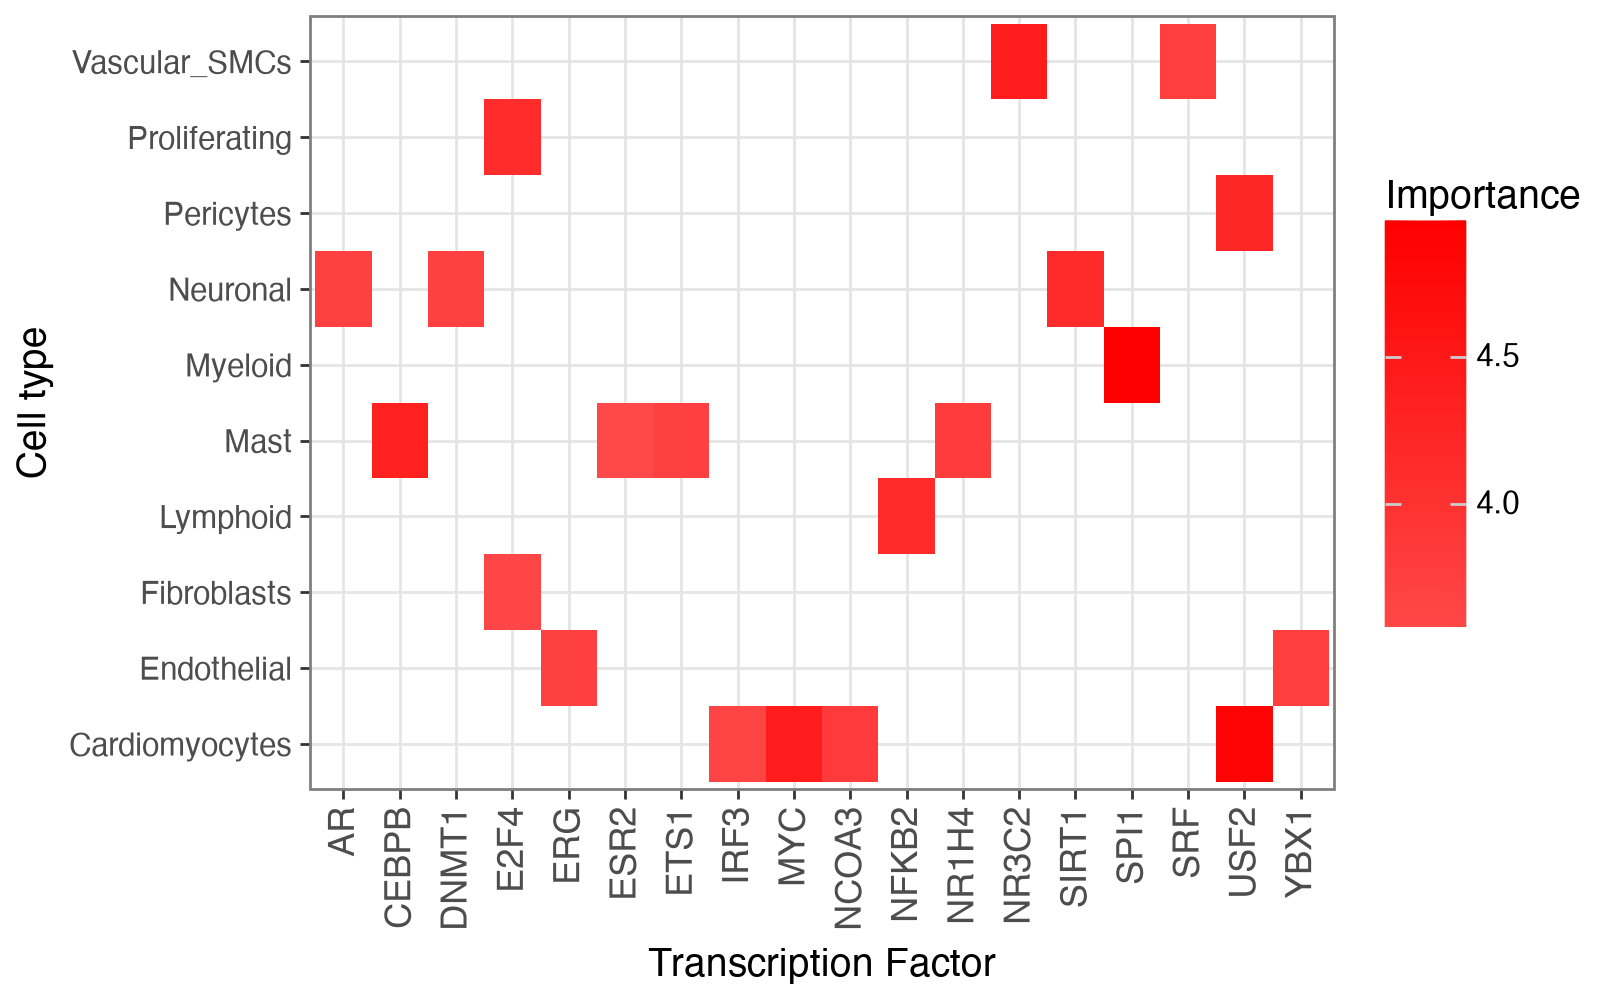

In [39]:
(
    li.pl.misty_interactions(misty, view='TFs', top_n=20) + 
    p9.labs(x='Transcription Factor', y='Cell type') +
    p9.theme_bw(base_size=14) +
    p9.theme(axis_text_x=p9.element_text(rotation=90, size=13)) +
    # change to blue-red
    p9.scale_fill_gradient2(low='blue', mid='white', high='red')+
    p9.theme(figure_size=(8, 5)) 
)


---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise — Where is a ligand–receptor interaction active?**

This exercise combines the previous notebook with this one. Use the local LR scores from
`li.mt.bivariate` as MISTy **targets**, and ask: *which cell types — in the same spot, or
in the surrounding tissue — explain where each interaction is active?*

1. Compute spatial neighbours on `adata` (`bandwidth=150`) and run `li.mt.bivariate`
   (`local_name='cosine'`, `global_name='morans'`, `nz_prop=0.3`).
2. Keep the 20 most spatially variable interactions (highest `morans`) as the intra view.
3. Build two views from the cell-type compositions `comps`:
   - `local`: the composition of the **same spot** — give it an identity connectivity,
     `scipy.sparse.identity(comps.n_obs, format='csr')`, in `.obsp['spatial_connectivities']`;
   - `nearby`: the composition of the **neighbourhood** — `li.pp.spatial_neighbors` with
     `bandwidth=200` and `set_diag=False`.
4. Fit `MistyData(data={'intra': ..., 'local': ..., 'nearby': ...})` with a
   `RandomForestModel` and `bypass_intra=True`, so that only cell types (not other LR
   pairs) are used as predictors.

Then look at which interactions are well explained, which view explains them, and which
cell type is behind the best-explained ones.
</div>

In [40]:
# your turn
from scipy import sparse

<details>
<summary><b>▶ Solution</b></summary>

```python
from scipy import sparse

# 1. local LR scores (as in the bivariate notebook)
li.pp.spatial_neighbors(adata, bandwidth=150, cutoff=0.1, kernel='gaussian', set_diag=True)
lrdata = li.mt.bivariate(adata, resource_name='consensus', local_name='cosine',
                         global_name='morans', nz_prop=0.3, use_raw=False)

# 2. targets: the 20 most spatially variable interactions
top_lrs = lrdata.var.sort_values('morans', ascending=False).head(20).index
lr_targets = lrdata[:, top_lrs].copy()

# 3. predictors: cell-type compositions in the same spot and in the neighbourhood
local = comps.copy()
local.obsp['spatial_connectivities'] = sparse.identity(comps.n_obs, format='csr')
nearby = comps.copy()
li.pp.spatial_neighbors(nearby, bandwidth=200, cutoff=0.05, set_diag=False)

# 4. fit; bypass_intra so that LR pairs are not used to predict each other
misty = MistyData(data={'intra': lr_targets, 'local': local, 'nearby': nearby})
misty(model=RandomForestModel, n_jobs=-1, seed=1337, bypass_intra=True, verbose=True)
```

**Which interactions are explained?** Because `bypass_intra=True`, `intra_R2` is 0 and
`multi_R2` is the variance explained by cell types alone.

```python
li.pl.misty_target_metrics(misty, stat='multi_R2')
```

All 20 interactions are well explained (R² ≈ 0.8–0.9): where an interaction is active is
largely determined by which cell types are there.

**Here or nearby?** The contributions show which view carries that information.

```python
li.pl.misty_contributions(misty)
```

The `nearby` view dominates (≳ 90 % for every target). Part of this is biology — signalling
depends on the surrounding tissue — but part of it is by construction: the local bivariate
score is itself computed over a neighbourhood (`bandwidth=150`), so a neighbourhood-level
composition matches it best. Keep this in mind before reading "nearby" as "paracrine".

**Which cell types?** Importances from a random forest are non-negative, so use a
sequential colour scale.

```python
(li.pl.misty_interactions(misty, view='nearby', top_n=20, return_fig=True)
 + p9.scale_fill_gradient(low='#fff5eb', high='#b30000')
 + p9.theme(figure_size=(8, 5)))
```

Two groups stand out. The collagen–integrin interactions (`COL1A1^ITGA11_ITGB1`,
`COL1A2^…`, `COL3A1^…`, …) are explained by **fibroblasts** — collagen deposition by
fibroblasts through integrin α11β1 is a hallmark of the fibrotic, ischemic zone. Interactions
such as `S100A1^RYR2`, `LPL^VLDLR` and `VTN^ITGAV_ITGB1` are explained by
**cardiomyocytes**, i.e. they mark the remaining viable myocardium.

**Check one on the tissue.** Put the interaction next to its top predictor, in the same
spot and in the neighbourhood (the smoothed values MISTy actually used):

```python
sq.pl.spatial_scatter(lr_targets, color='COL1A1^ITGA11_ITGB1', cmap='magma', size=1.3)
sq.pl.spatial_scatter(comps, color='Fibroblasts', cmap='viridis', size=1.3,
                      title='Fibroblasts (same spot)')
sq.pl.spatial_scatter(misty.mod['nearby'], color='Fibroblasts', cmap='viridis', size=1.3,
                      title='Fibroblasts (neighbourhood)')
plt.show()
```

The interaction map follows the fibroblast-rich regions, and it matches the smoothed
neighbourhood composition more closely than the noisier per-spot one — which is what the
contributions plot said.

</details>

---

**Next:** the single-cell resolution track in `../image/`, starting with `00_setup.ipynb`.